# Import and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Load
df = pd.read_csv("../data/raw/ovela_weekly_data.csv", parse_dates=["date"])

print(f"Shape: {df.shape}")
print(f"\nDate range: {df.date.min().date()} to {df.date.max().date()}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (104, 10)

Date range: 2022-01-03 to 2023-12-25

Column types:
date                datetime64[ns]
revenue                    float64
meta_spend                 float64
google_spend               float64
tiktok_spend               float64
email_spend                float64
influencer_spend             int64
promo_flag                   int64
week_of_year                 int64
year                         int64
dtype: object

Missing values:
date                0
revenue             0
meta_spend          0
google_spend        0
tiktok_spend        0
email_spend         0
influencer_spend    0
promo_flag          0
week_of_year        0
year                0
dtype: int64


# Summary Statistics

In [2]:
# Summary stats — formatted for readability
summary = df.describe().T
summary.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]

# Format dollar columns
dollar_cols = ["revenue", "meta_spend", "google_spend",
               "tiktok_spend", "email_spend", "influencer_spend"]

print("Summary statistics:\n")
for col in dollar_cols:
    row = summary.loc[col]
    print(f"{col:<20} mean: ${row['mean']:>8,.0f}  "
          f"std: ${row['std']:>7,.0f}  "
          f"min: ${row['min']:>7,.0f}  "
          f"max: ${row['max']:>7,.0f}")

Summary statistics:

revenue              mean: $ 178,887  std: $148,993  min: $166,420  max: $ 14,357
meta_spend           mean: $  18,730  std: $ 12,245  min: $ 16,229  max: $  3,342
google_spend         mean: $  12,064  std: $  8,638  min: $ 10,975  max: $  1,546
tiktok_spend         mean: $   8,073  std: $  3,188  min: $  5,822  max: $  2,616
email_spend          mean: $   1,566  std: $    809  min: $  1,248  max: $    421
influencer_spend     mean: $   1,673  std: $      0  min: $      0  max: $  3,095


# Revenue trend

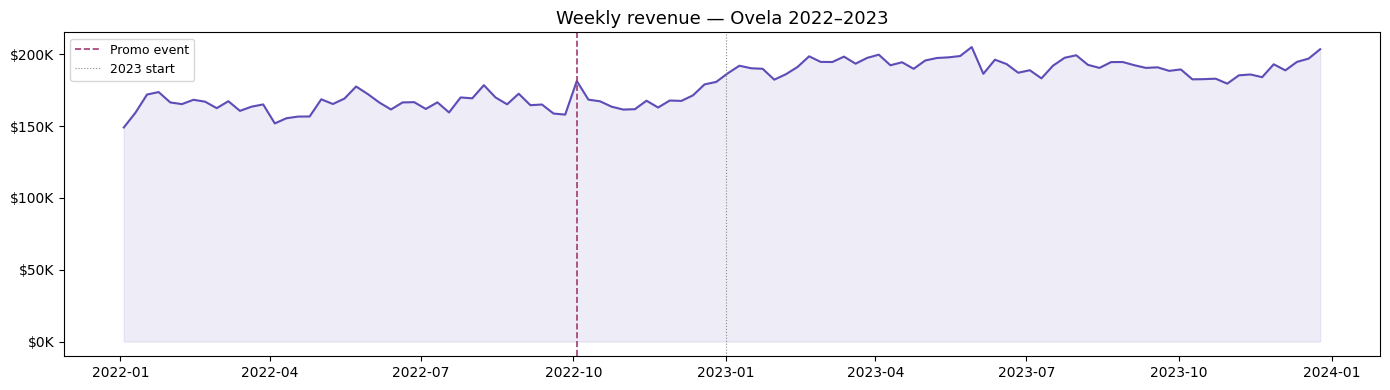

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.date, df.revenue, color="#5C4DB7", linewidth=1.5)
ax.fill_between(df.date, df.revenue, alpha=0.1, color="#5C4DB7")

# Mark the promo week
promo_date = df.loc[df.promo_flag == 1, "date"].values[0]
ax.axvline(promo_date, color="#A23B72", linewidth=1.2,
           linestyle="--", label="Promo event")

# Year divider
ax.axvline(pd.Timestamp("2023-01-01"), color="#888780",
           linewidth=0.8, linestyle=":", label="2023 start")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
ax.set_title("Weekly revenue — Ovela 2022–2023", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/charts/02_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# Total spend by channel

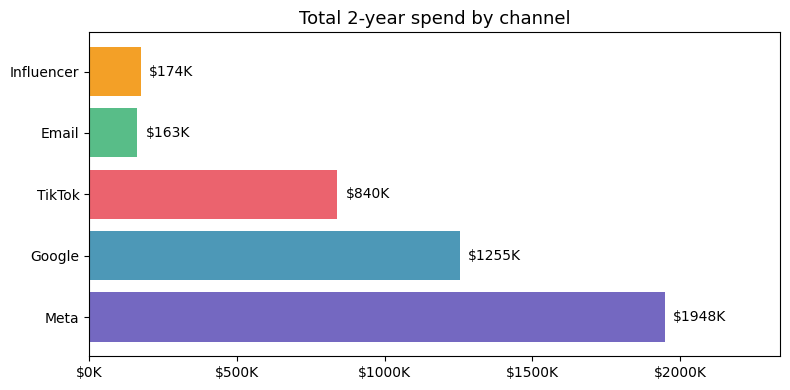

Share of total spend:
  Meta         44.5%
  Google       28.7%
  TikTok       19.2%
  Email        3.7%
  Influencer   4.0%


In [4]:
spend_cols = ["meta_spend", "google_spend", "tiktok_spend",
              "email_spend", "influencer_spend"]
labels = ["Meta", "Google", "TikTok", "Email", "Influencer"]
colors = ["#5C4DB7", "#2E86AB", "#E84855", "#3BB273", "#F18F01"]

totals = df[spend_cols].sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(labels, totals.values, color=colors, alpha=0.85)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
ax.set_title("Total 2-year spend by channel", fontsize=13)
ax.bar_label(bars, labels=[f"${v/1000:.0f}K" for v in totals.values],
             padding=6, fontsize=10)
ax.set_xlim(0, totals.max() * 1.2)
plt.tight_layout()
plt.savefig("../outputs/charts/02_spend_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

# Share of spend
print("Share of total spend:")
for label, val in zip(labels, totals.values):
    print(f"  {label:<12} {val/totals.sum()*100:.1f}%")

# Spend vs. revenue correlation

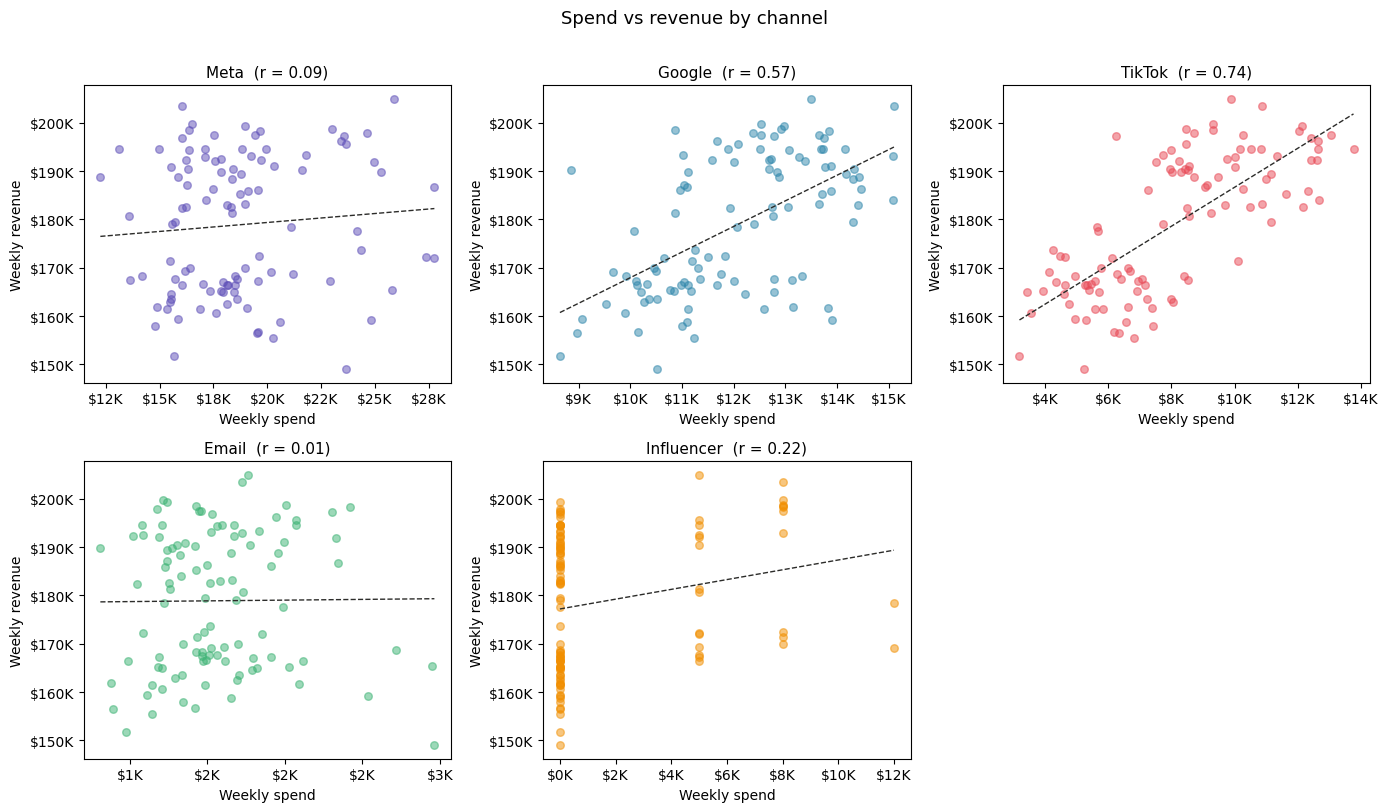

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

channel_pairs = [
    ("meta_spend",        "Meta",        "#5C4DB7"),
    ("google_spend",      "Google",      "#2E86AB"),
    ("tiktok_spend",      "TikTok",      "#E84855"),
    ("email_spend",       "Email",       "#3BB273"),
    ("influencer_spend",  "Influencer",  "#F18F01"),
]

for ax, (col, label, color) in zip(axes, channel_pairs):
    ax.scatter(df[col], df.revenue, alpha=0.5, color=color, s=30)

    # Fit a simple trend line
    z = np.polyfit(df[col], df.revenue, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color="#2C2C2A", linewidth=1, linestyle="--")

    corr = df[col].corr(df.revenue)
    ax.set_title(f"{label}  (r = {corr:.2f})", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"${x/1000:.0f}K"))
    ax.set_xlabel("Weekly spend")
    ax.set_ylabel("Weekly revenue")

axes[-1].set_visible(False)
fig.suptitle("Spend vs revenue by channel", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/charts/02_spend_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation heatmap   

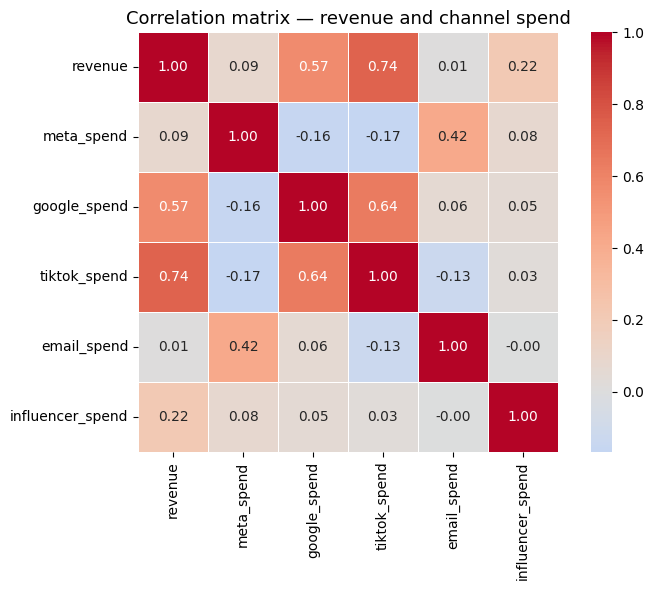

In [6]:
corr_cols = ["revenue"] + spend_cols
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation matrix — revenue and channel spend", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/charts/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key observations

- **Revenue** shows a clear upward trend with seasonal variation — January and May
  peaks are visible, consistent with fertility awareness patterns
- **Meta** has the highest total spend and a moderate revenue correlation —
  but correlation alone overstates its role due to seasonal co-movement
- **Google** shows a strong positive correlation despite lower spend —
  early signal of efficiency
- **TikTok** spend ramps up in year 2 — correlation will be noisy early
- **Influencer** is sporadic — low correlation expected, hard to attribute
- **Multicollinearity risk**: Meta and Google spend move together seasonally —
  this will need to be handled carefully in the MMM

These observations motivate the MMM — simple correlation can't untangle
channel effects from each other or from seasonality.